In [51]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder

In [52]:
pdf = pd.read_csv('waterquality.csv')
water = pd.DataFrame(pdf)

print(f"Number of rows: {water.shape[0]}")
print(f"Number of columns: {water.shape[1]}")

Number of rows: 2371
Number of columns: 8


In [53]:
water.iloc[1001:1021]

,Date,Salinity (ppt),DissolvedOxygen (mg/L),pH,SecchiDepth (m),WaterDepth (m),WaterTemp (C),AirTemp (C)
1001,2005-08-11,0.0,3.7,6.5,0.60,0.60,27.0,29.444444
1002,2005-08-11,0.0,2.9,6.5,0.40,0.80,31.0,29.444444
1003,2005-08-11,0.0,NaN,7.0,0.60,0.60,31.0,30.000000
1004,2005-08-24,0.0,NaN,7.0,0.50,0.70,27.0,22.777778
1005,2005-08-24,0.0,2.5,NaN,0.70,1.50,27.0,22.777778
1006,2005-08-24,0.0,4.9,6.0,0.45,0.45,25.0,22.777778
1007,2005-08-24,0.0,3.6,7.0,0.30,0.30,25.0,22.777778
1008,2005-08-24,0.0,NaN,7.5,0.20,0.20,27.0,22.777778
1009,2005-09-08,0.0,2.4,7.0,0.10,0.10,26.0,23.333333
1010,2005-09-08,0.0,NaN,8.0,0.10,0.10,25.0,23.333333


In [54]:
water.describe(include = 'all')

,Date,Salinity (ppt),DissolvedOxygen (mg/L),pH,SecchiDepth (m),WaterDepth (m),WaterTemp (C),AirTemp (C)
count,2366,2241.000000,1520.000000,2276.000000,2298.000000,2300.000000,2250.000000,2371.000000
unique,801,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2017-04-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.717068,6.646263,7.168212,0.524898,0.762559,18.062138,15.663050
std,NaN,1.230819,2.506608,0.788485,0.473663,0.621140,8.298246,10.314720
min,NaN,0.000000,0.000000,0.300000,0.000000,0.010000,0.000000,-17.777778
25%,NaN,0.000000,4.800000,6.500000,0.300000,0.400000,11.000000,8.888889
50%,NaN,0.000000,6.500000,7.000000,0.400000,0.650000,19.000000,16.666667
75%,NaN,1.000000,8.500000,7.500000,0.650000,0.950000,25.000000,23.888889


In [55]:
water.info()

<class 'pandas.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    2366 non-null   str    
 1   Salinity (ppt)          2241 non-null   float64
 2   DissolvedOxygen (mg/L)  1520 non-null   float64
 3   pH                      2276 non-null   float64
 4   SecchiDepth (m)         2298 non-null   float64
 5   WaterDepth (m)          2300 non-null   float64
 6   WaterTemp (C)           2250 non-null   float64
 7   AirTemp (C)             2371 non-null   float64
dtypes: float64(7), str(1)
memory usage: 148.3 KB


In [56]:
water.isnull().sum()

Date                        5
Salinity (ppt)            130
DissolvedOxygen (mg/L)    851
pH                         95
SecchiDepth (m)            73
WaterDepth (m)             71
WaterTemp (C)             121
AirTemp (C)                 0
dtype: int64

In [57]:
water.head()

,Date,Salinity (ppt),DissolvedOxygen (mg/L),pH,SecchiDepth (m),WaterDepth (m),WaterTemp (C),AirTemp (C)
0,1989-05-11,NaN,NaN,7.5,0.3,0.9,17.0,-17.777778
1,1989-05-18,NaN,12.0,7.5,0.2,0.6,17.5,20.500000
2,1989-05-25,NaN,NaN,8.0,0.4,0.8,23.0,25.000000
3,1989-06-01,NaN,12.0,8.0,0.4,0.9,25.5,29.000000
4,1989-07-11,NaN,NaN,8.5,0.3,0.9,28.5,28.000000


In [58]:
water.dtypes

Date                          str
Salinity (ppt)            float64
DissolvedOxygen (mg/L)    float64
pH                        float64
SecchiDepth (m)           float64
WaterDepth (m)            float64
WaterTemp (C)             float64
AirTemp (C)               float64
dtype: object

In [59]:
water['WaterDepth (m)']=water['WaterDepth (m)'].fillna(water['WaterDepth (m)'].mean())
water['SecchiDepth (m)']=water['SecchiDepth (m)'].fillna(water['SecchiDepth (m)'].mean())
water['Salinity (ppt)']=water['Salinity (ppt)'].fillna(water['Salinity (ppt)'].mean())
water['WaterTemp (C)']=water['WaterTemp (C)'].fillna(water['WaterTemp (C)'].mean())
water['Salinity (ppt)']=water['Salinity (ppt)'].fillna(water['Salinity (ppt)'].mean())
water['pH']=water['pH'].fillna(water['pH'].mean())
water['DissolvedOxygen (mg/L)']=water['DissolvedOxygen (mg/L)'].fillna(water['DissolvedOxygen (mg/L)'].mean())

water.drop(['Date'],inplace=True,axis=1)
water.head()


,Salinity (ppt),DissolvedOxygen (mg/L),pH,SecchiDepth (m),WaterDepth (m),WaterTemp (C),AirTemp (C)
0,0.717068,6.646263,7.5,0.3,0.9,17.0,-17.777778
1,0.717068,12.000000,7.5,0.2,0.6,17.5,20.500000
2,0.717068,6.646263,8.0,0.4,0.8,23.0,25.000000
3,0.717068,12.000000,8.0,0.4,0.9,25.5,29.000000
4,0.717068,6.646263,8.5,0.3,0.9,28.5,28.000000


In [60]:
water.isnull().sum()

Salinity (ppt)            0
DissolvedOxygen (mg/L)    0
pH                        0
SecchiDepth (m)           0
WaterDepth (m)            0
WaterTemp (C)             0
AirTemp (C)               0
dtype: int64

In [61]:
water.dtypes

Salinity (ppt)            float64
DissolvedOxygen (mg/L)    float64
pH                        float64
SecchiDepth (m)           float64
WaterDepth (m)            float64
WaterTemp (C)             float64
AirTemp (C)               float64
dtype: object

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
water_scaled = scaler.fit_transform(water)

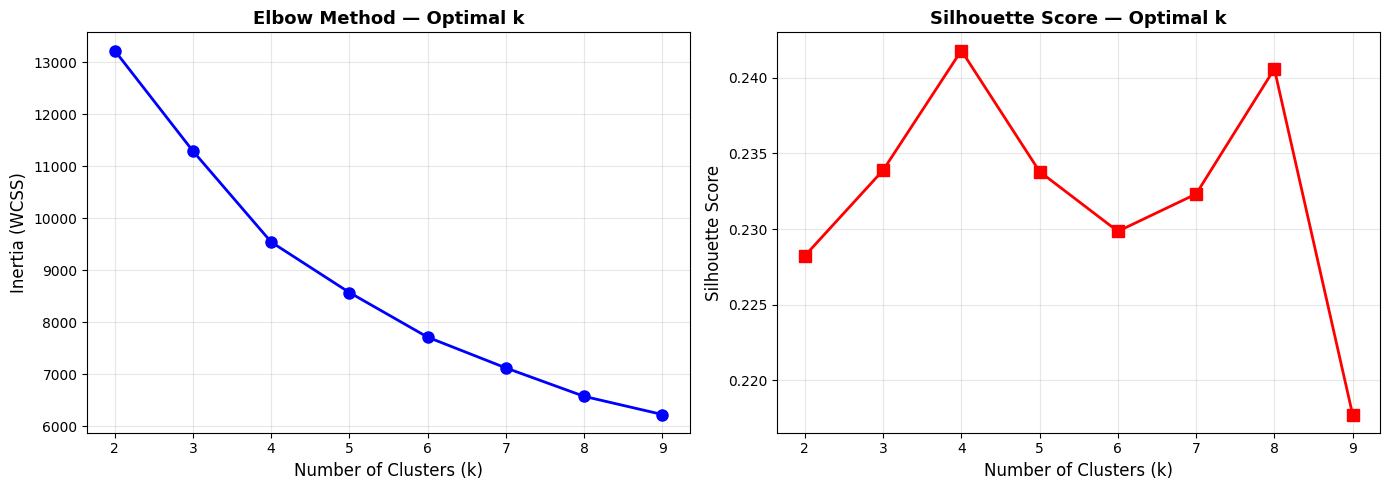


Based on the elbow in the inertia curve and highest silhouette score,
optimal k = 4


In [63]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# Determine optimal k using Elbow Method and Silhouette Score
inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(water_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(water_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method — Optimal k', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score — Optimal k', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBased on the elbow in the inertia curve and highest silhouette score,")
print("optimal k =", list(K_range)[silhouettes.index(max(silhouettes))])

In [64]:
# Apply K-Means with optimal k=7
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
water['Cluster'] = kmeans.fit_predict(water_scaled)

print("=== Cluster Labels ===")
print(water['Cluster'].values)

print("\n=== Cluster Distribution ===")
print(water['Cluster'].value_counts().sort_index())

=== Cluster Labels ===
[0 1 3 ... 3 3 0]

=== Cluster Distribution ===
Cluster
0    961
1    425
2     13
3    972
Name: count, dtype: int64


In [65]:
# 3.4 Principal Component Analysis — reduce to 2 dimensions
X = water.drop(columns=['Cluster'])
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("=== Dimensions Before and After PCA ===")
print(f"Original dataset dimensions   : {X_scaled.shape}")
print(f"PCA-transformed dimensions    : {X_pca.shape}")

print("\n=== Principal Components (Feature Loadings) ===")
pc_df = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=['PC1', 'PC2'])
display(pc_df.round(4))

print("=== Explained Variance ===")
print(f"PC1 explained variance ratio : {pca.explained_variance_ratio_[0]:.4f}  ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"PC2 explained variance ratio : {pca.explained_variance_ratio_[1]:.4f}  ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"Total explained variance     : {pca.explained_variance_ratio_.sum():.4f}  ({pca.explained_variance_ratio_.sum()*100:.1f}%)")
print(f"\nExplained variance values    : {np.round(pca.explained_variance_, 4)}")

=== Dimensions Before and After PCA ===
Original dataset dimensions   : (2371, 7)
PCA-transformed dimensions    : (2371, 2)

=== Principal Components (Feature Loadings) ===


,PC1,PC2
Salinity (ppt),-0.1762,-0.2378
DissolvedOxygen (mg/L),0.1851,-0.4326
pH,-0.3362,-0.0656
SecchiDepth (m),0.4974,0.4048
WaterDepth (m),0.4758,0.4115
WaterTemp (C),-0.4203,0.4888
AirTemp (C),-0.4139,0.4242


=== Explained Variance ===
PC1 explained variance ratio : 0.2839  (28.4%)
PC2 explained variance ratio : 0.2701  (27.0%)
Total explained variance     : 0.5541  (55.4%)

Explained variance values    : [1.9883 1.8918]


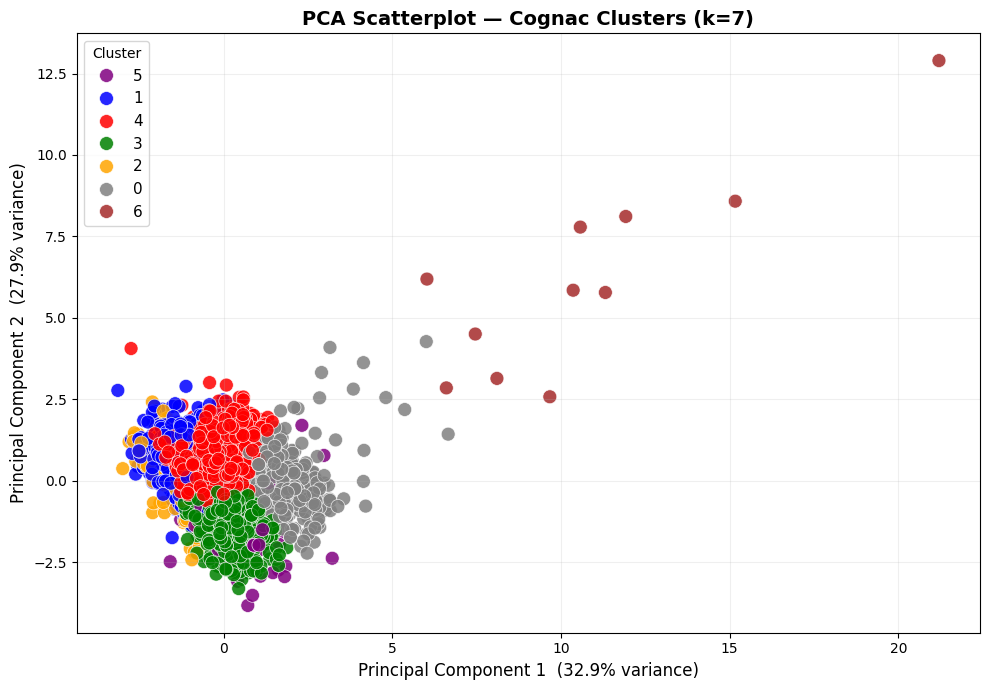

In [50]:
# Seaborn scatterplot of PCA components coloured by cluster
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = water['Cluster'].astype(str)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='Cluster',
    palette={'0':'grey','1': 'blue',
    '2': 'orange',
    '3': 'green',  # Added missing key
    '4': 'red',    # Added missing key
    '5': 'purple', # Added missing key
    '6': 'brown'},
    s=100, alpha=0.85, edgecolor='white', linewidth=0.5)
plt.title('PCA Scatterplot — Cognac Clusters (k=7)', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'Principal Component 2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.legend(title='Cluster', fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()